In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Item 1

**1. Carga de Datos**

In [2]:
df = pd.read_csv('weatherAUS_2026C1.csv')
df.head(5)

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


**1. ANÁLISIS DESCRIPTIVO INICIAL**

In [3]:
print("--- Estructura del Dataset ---")
print(df.info())
print("\n--- Estadísticas Descriptivas ---")
print(df.describe().T)

# ¿Qué es cada variable? (Resumen rápido)
# Numéricas: Temperaturas, Humedad, Presión, Velocidad viento (continuas).
# Categóricas: Location, WindDir, RainToday (factores).

--- Estructura del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  

**2. ANÁLISIS DE DATOS FALTANTES**

In [4]:
print("\n--- Porcentaje de datos faltantes por columna ---")
missing_props = df.isnull().mean() * 100
print(missing_props[missing_props > 0].sort_values(ascending=False))

# Decisión: Eliminamos filas donde el target (RainTomorrow) es nulo
df = df.dropna(subset=['RainTomorrow'])


--- Porcentaje de datos faltantes por columna ---
Sunshine            47.998790
Evaporation         43.155998
Cloud3pm            40.805436
Cloud9am            38.421863
Pressure9am         10.357467
Pressure3pm         10.332022
WindDir9am           7.263500
WindGustDir          7.094325
WindGustSpeed        7.051000
Humidity3pm          3.098094
WindDir3pm           2.906225
Temp3pm              2.480538
Rainfall             2.241906
RainToday            2.241906
RainfallTomorrow     2.241218
RainTomorrow         2.241218
WindSpeed3pm         2.105053
Humidity9am          1.824471
WindSpeed9am         1.215168
Temp9am              1.214480
MinTemp              1.020549
MaxTemp              0.861690
dtype: float64


**3. VISUALIZACIÓN DE DATOS**

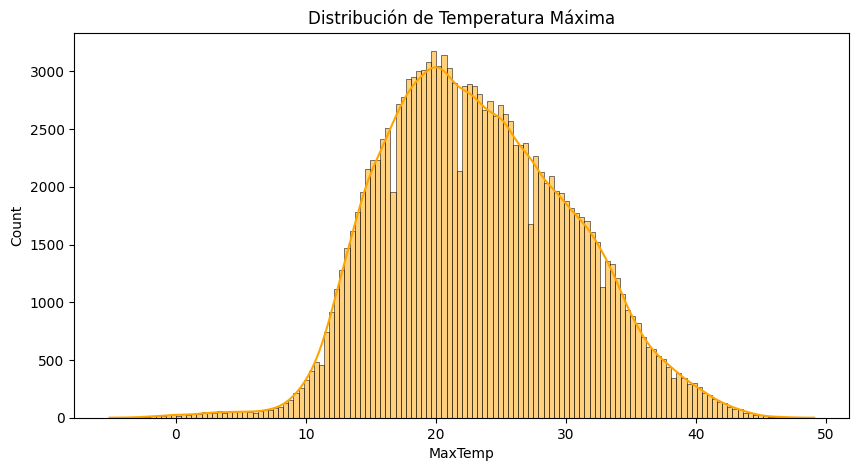

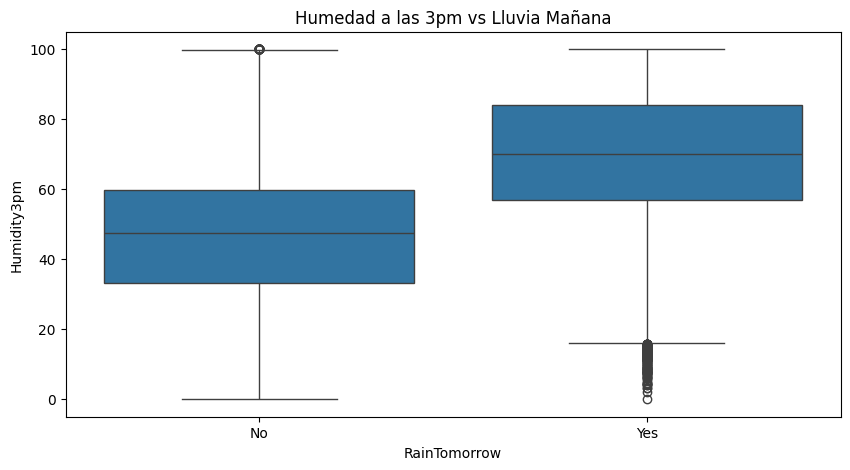

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['MaxTemp'], kde=True, color='orange')
plt.title('Distribución de Temperatura Máxima')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df)
plt.title('Humedad a las 3pm vs Lluvia Mañana')
plt.show()

**4. BALANCE DEL DATASET**

In [6]:
print("\n--- Balance del Target (RainTomorrow) ---")
balance = df['RainTomorrow'].value_counts(normalize=True) * 100
print(balance)

# ¿Por qué preguntamos esto? 
# Respuesta: Si hay un desbalance fuerte (por ejemplo: No = 80%: y Yes = 20%), el modelo podría 
# aprender a predecir siempre "No" y tener alta precisión pero ser inútil.


--- Balance del Target (RainTomorrow) ---
RainTomorrow
No     77.579087
Yes    22.420913
Name: proportion, dtype: float64


**5. CODIFICACIÓN DE VARIABLES CATEGÓRICAS (Pre-Split)**

In [7]:
# Codificamos binarias manualmente
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Para el resto (Location, WindDir), usaremos One-Hot encoding después o LabelEncoding ahora
# Aquí simplificamos con LabelEncoding para las direcciones y locación para facilitar la matriz
le = LabelEncoder()
cat_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

**6. VALIDACIÓN CRUZADA (DIVISIÓN TRAIN - TEST)**

In [8]:
# Se hace aquí para evitar que el escalado "vea" información del set de prueba.
X = df.drop(['RainTomorrow', 'Date', 'Unnamed: 0', 'RainfallTomorrow'], axis=1, errors='ignore')
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nSet Entrenamiento: {X_train.shape}")
print(f"Set Prueba: {X_test.shape}")


Set Entrenamiento: (113722, 21)
Set Prueba: (28431, 21)


**7. MATRIZ DE CORRELACIÓN**

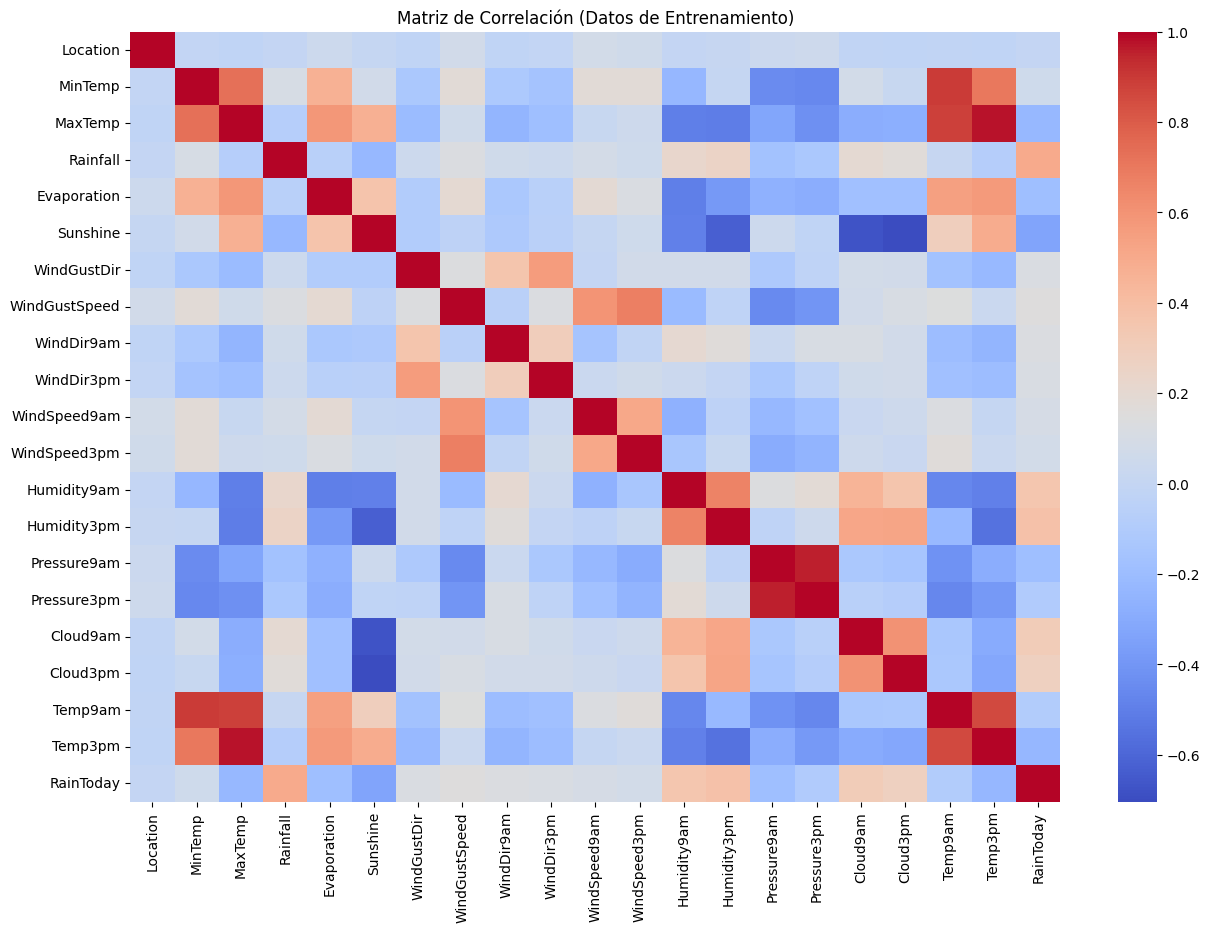

In [9]:
plt.figure(figsize=(15, 10))
sns.heatmap(X_train.corr(), annot=False, cmap='coolwarm')
plt.title('Matriz de Correlación (Datos de Entrenamiento)')
plt.show()

**8. ESTANDARIZACIÓN / ESCALADO**

In [10]:
# Imputamos nulos con la mediana antes de escalar (usando solo info de train)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median()) # Ojo: usamos la mediana de TRAIN en TEST

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Procesamiento Completado ---")
print("Datos listos para entrenamiento de modelos.")


--- Procesamiento Completado ---
Datos listos para entrenamiento de modelos.


# Item 2

**9. MODELO DE CLASIFICACIÓN CON REGRESIÓN LOGÍSTICA**

Se entrena una regresión logística usando los datos ya imputados y escalados. La clase positiva es `RainTomorrow = 1`

In [11]:
# Entrenamos el modelo
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_scaled, y_train)

# Predicciones con el umbral por defecto de 0.5
y_train_pred_logreg = log_reg.predict(X_train_scaled)
y_test_pred_logreg = log_reg.predict(X_test_scaled)

# Probabilidades de la clase positiva (RainTomorrow = 1)
y_train_proba_logreg = log_reg.predict_proba(X_train_scaled)[:, 1]
y_test_proba_logreg = log_reg.predict_proba(X_test_scaled)[:, 1]

**10. MÉTRICAS DEL MODELO**

In [12]:
# Función auxiliar para calcular las métricas
def calcular_metricas(y_real, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_real, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1_score": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, y_proba)
    }

metricas_logreg = pd.DataFrame(
    [
        calcular_metricas(y_train, y_train_pred_logreg, y_train_proba_logreg),
        calcular_metricas(y_test, y_test_pred_logreg, y_test_proba_logreg)
    ],
    index=["Train", "Test"]
)

metricas_logreg

,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc
Train,0.84288,0.717322,0.719986,0.489685,0.582913,0.862456
Test,0.84232,0.716996,0.717207,0.489802,0.582083,0.863056


In [13]:
# Reporte
print("Reporte de clasificación - Regresión logística")
print(
    classification_report(
        y_test,
        y_test_pred_logreg,
        target_names=["No llueve", "Llueve"],
        zero_division=0
    )
)

Reporte de clasificación - Regresión logística
              precision    recall  f1-score   support

   No llueve       0.86      0.94      0.90     22057
      Llueve       0.72      0.49      0.58      6374

    accuracy                           0.84     28431
   macro avg       0.79      0.72      0.74     28431
weighted avg       0.83      0.84      0.83     28431



**11. MATRIZ DE CONFUSIÓN**

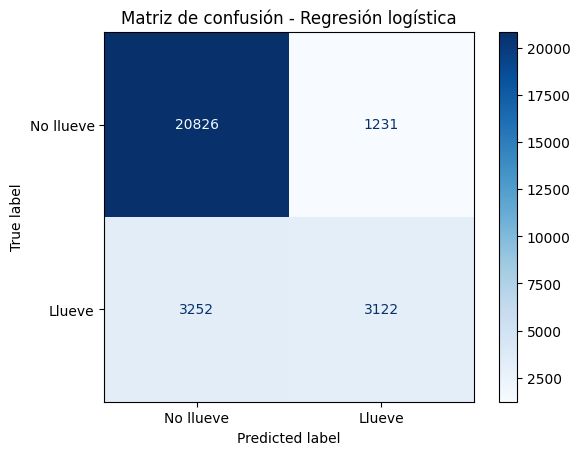

In [14]:
# Generamos gráfico
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_logreg,
    display_labels=["No llueve", "Llueve"],
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [15]:
# Obtenemos los valores de la matriz
cm_logreg = confusion_matrix(y_test, y_test_pred_logreg, labels=[0, 1])

tn, fp, fn, tp = cm_logreg.ravel()

print("Verdaderos negativos:", tn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", tp)

Verdaderos negativos: 20826
Falsos positivos: 1231
Falsos negativos: 3252
Verdaderos positivos: 3122


**12. CURVA ROC Y AUC**

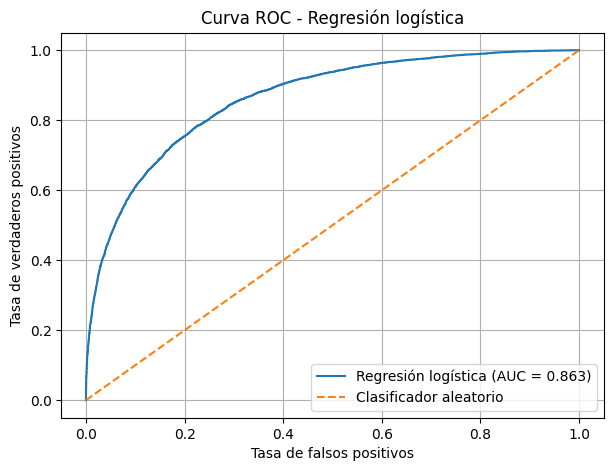

In [16]:
# Calculamos la curva ROC usando las probabilidades de la clase positiva
fpr_logreg, tpr_logreg, thresholds_logreg = roc_curve(y_test, y_test_proba_logreg)

auc_logreg = roc_auc_score(y_test, y_test_proba_logreg)

plt.figure(figsize=(7, 5))
plt.plot(fpr_logreg, tpr_logreg, label=f"Regresión logística (AUC = {auc_logreg:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.grid(True)
plt.show()

**13. ANÁLISIS DEL UMBRAL**

El umbral 0.5 es el valor por defecto, pero no siempre es el más conveniente. Probamos un umbral alternativo usando el índice de Youden

In [17]:
# Buscamos el umbral que maximiza el índice de Youden
youden_index = tpr_logreg - fpr_logreg
best_index = np.argmax(youden_index)

best_threshold_logreg = thresholds_logreg[best_index]

print("Mejor umbral según Youden:", best_threshold_logreg)
print("TPR:", tpr_logreg[best_index])
print("FPR:", fpr_logreg[best_index])

Mejor umbral según Youden: 0.2057803767061513
TPR: 0.783966112331346
FPR: 0.2255066418823956


In [18]:
# Generamos predicciones usando el umbral ajustado
y_test_pred_logreg_umbral = (y_test_proba_logreg >= best_threshold_logreg).astype(int)

print("Reporte con umbral ajustado")
print(
    classification_report(
        y_test,
        y_test_pred_logreg_umbral,
        target_names=["No llueve", "Llueve"],
        zero_division=0
    )
)

Reporte con umbral ajustado
              precision    recall  f1-score   support

   No llueve       0.93      0.77      0.84     22057
      Llueve       0.50      0.78      0.61      6374

    accuracy                           0.78     28431
   macro avg       0.71      0.78      0.73     28431
weighted avg       0.83      0.78      0.79     28431



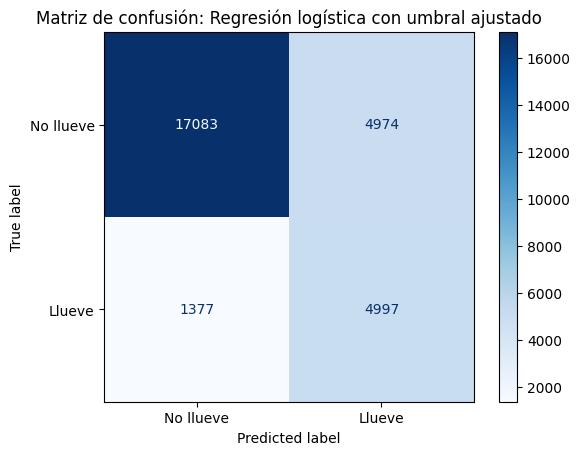

In [19]:
# Matriz de confusión con el umbral ajustado
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_logreg_umbral,
    display_labels=["No llueve", "Llueve"],
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión: Regresión logística con umbral ajustado")
plt.show()

In [20]:
# Comparamos las métricas usando el umbral 0.5 y el umbral ajustado
comparacion_umbrales_logreg = pd.DataFrame(
    [
        calcular_metricas(y_test, y_test_pred_logreg, y_test_proba_logreg),
        calcular_metricas(y_test, y_test_pred_logreg_umbral, y_test_proba_logreg)
    ],
    index=["Umbral 0.5", f"Umbral ajustado ({best_threshold_logreg:.3f})"]
)

comparacion_umbrales_logreg

,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc
Umbral 0.5,0.842320,0.716996,0.717207,0.489802,0.582083,0.863056
Umbral ajustado (0.206),0.776617,0.779230,0.501153,0.783966,0.611441,0.863056


**14. ANÁLISIS DEL FITTING**

Para analizar el fitting se comparan las métricas de train y test. Si los valores son parecidos, el modelo generaliza de forma razonable. Si train es mucho mejor que test, podría haber sobreajuste

In [21]:
# Observamos las variables con coeficientes de mayor magnitud
coeficientes_logreg = pd.DataFrame({
    "variable": X_train.columns,
    "coeficiente": log_reg.coef_[0]
})

coeficientes_logreg["coeficiente_abs"] = coeficientes_logreg["coeficiente"].abs()

coeficientes_logreg.sort_values("coeficiente_abs", ascending=False).head(15)

,variable,coeficiente,coeficiente_abs
15,Pressure3pm,-1.168963,1.168963
13,Humidity3pm,1.084467,1.084467
14,Pressure9am,0.774362,0.774362
7,WindGustSpeed,0.671195,0.671195
5,Sunshine,-0.293170,0.293170
17,Cloud3pm,0.292509,0.292509
2,MaxTemp,-0.234562,0.234562
20,RainToday,0.220556,0.220556
11,WindSpeed3pm,-0.189413,0.189413
19,Temp3pm,0.154161,0.154161


# Item 3

**15. MODELO BASE**

Se implementa un `DummyClassifier` como modelo base. Este modelo no aprende patrones de las variables, sino que usa la distribución de clases del conjunto de entrenamiento. La estrategia es `stratified`, que predice proporcional a la cantidad de casos de la clase mayoritaria.

Su objetivo no es obtener buen rendimiento, sino establecer una referencia mínima contra la cual comparar modelos más complejos. En este problema que está en gran medida desbalanceado, este baseline permite evaluar si la regresión logística mejora realmente respecto a apostar siempre a la clase mayoritaria.

In [25]:
base = DummyClassifier(strategy='stratified', random_state=42)
base.fit(X_train, y_train)
y_pred_base = base.predict(X_test)

In [34]:
# Entrenamos un modelo base que predice según la clase más frecuente.
base_model = DummyClassifier(strategy="stratified", random_state=42)

base_model.fit(X_train_scaled, y_train)

# Predicciones del modelo base.
y_train_pred_base = base_model.predict(X_train_scaled)
y_test_pred_base = base_model.predict(X_test_scaled)

# Probabilidades de la clase positiva: RainTomorrow = 1.
y_train_proba_base = base_model.predict_proba(X_train_scaled)[:, 1]
y_test_proba_base = base_model.predict_proba(X_test_scaled)[:, 1]

**16. MÉTRICAS DEL MODELO BASE**

Se calculan las mismas métricas que para la regresión logística para poder comparar ambos modelos.

In [35]:
metricas_base = pd.DataFrame(
    [
        calcular_metricas(y_train, y_train_pred_base, y_train_proba_base),
        calcular_metricas(y_test, y_test_pred_base, y_test_proba_base)
    ],
    index=["Train", "Test"]
)

metricas_base

,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc
Train,0.653031,0.501161,0.226017,0.225822,0.225919,0.501161
Test,0.655517,0.503794,0.230114,0.228742,0.229426,0.503794


In [36]:
# Reporte de clasificación para el modelo base.
print("Reporte de clasificación - Modelo base")
print(
    classification_report(
        y_test,
        y_test_pred_base,
        target_names=["No llueve", "Llueve"],
        zero_division=0
    )
)

Reporte de clasificación - Modelo base
              precision    recall  f1-score   support

   No llueve       0.78      0.78      0.78     22057
      Llueve       0.23      0.23      0.23      6374

    accuracy                           0.66     28431
   macro avg       0.50      0.50      0.50     28431
weighted avg       0.65      0.66      0.66     28431



In [37]:
# Comparación entre el modelo base y la regresión logística.
comparacion_modelos = pd.DataFrame(
    [
        calcular_metricas(y_test, y_test_pred_base, y_test_proba_base),
        calcular_metricas(y_test, y_test_pred_logreg, y_test_proba_logreg),
        calcular_metricas(y_test, y_test_pred_logreg_umbral, y_test_proba_logreg)
    ],
    index=[
        "Modelo base",
        "Regresión logística - umbral 0.5",
        f"Regresión logística - umbral ajustado ({best_threshold_logreg:.3f})"
    ]
)

comparacion_modelos

,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc
Modelo base,0.655517,0.503794,0.230114,0.228742,0.229426,0.503794
Regresión logística - umbral 0.5,0.842320,0.716996,0.717207,0.489802,0.582083,0.863056
Regresión logística - umbral ajustado (0.206),0.776617,0.779230,0.501153,0.783966,0.611441,0.863056


**17. MATRIZ DE CONFUSIÓN DEL MODELO BASE**

La matriz de confusión permite observar qué errores comete una estrategia simple que no usa las variables climáticas.

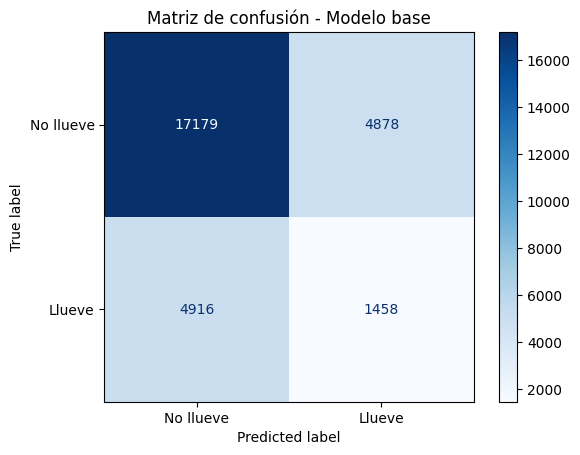

In [38]:
# Graficamos la matriz de confusión del modelo base.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_base,
    display_labels=["No llueve", "Llueve"],
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión - Modelo base")
plt.show()

In [39]:
# Obtenemos los valores de la matriz de confusión.
cm_base = confusion_matrix(y_test, y_test_pred_base, labels=[0, 1])

tn_base, fp_base, fn_base, tp_base = cm_base.ravel()

print("Verdaderos negativos:", tn_base)
print("Falsos positivos:", fp_base)
print("Falsos negativos:", fn_base)
print("Verdaderos positivos:", tp_base)

Verdaderos negativos: 17179
Falsos positivos: 4878
Falsos negativos: 4916
Verdaderos positivos: 1458


En el modelo base, los errores reflejan el comportamiento de una regla ingenua. Si la clase mayoritaria es “No llueve”, el modelo tenderá a fallar especialmente en los casos donde sí llueve.

**18. CURVA ROC Y AUC DEL MODELO BASE**

Se grafica la curva ROC del baseline para compararla luego con la regresión logística.

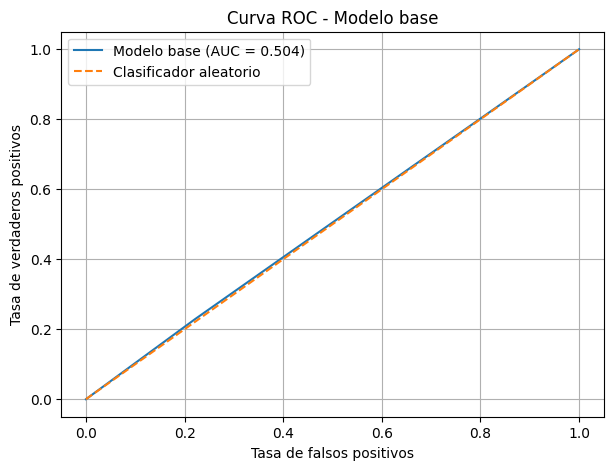

In [40]:
# Calculamos la curva ROC usando las probabilidades del modelo base.
fpr_base, tpr_base, thresholds_base = roc_curve(y_test, y_test_proba_base)

auc_base = roc_auc_score(y_test, y_test_proba_base)

plt.figure(figsize=(7, 5))
plt.plot(fpr_base, tpr_base, label=f"Modelo base (AUC = {auc_base:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Modelo base")
plt.legend()
plt.grid(True)
plt.show()

El modelo base funciona como una referencia mínima, ya que no utiliza las variables climáticas para aprender patrones. En comparación, la regresión logística obtiene un mejor desempeño en métricas como `balanced_accuracy`, `precision`, `recall`, `F1-score` y `ROC-AUC`.

El `accuracy` del modelo base puede parecer aceptable si el dataset está desbalanceado, pero esto no significa que el modelo sea útil. En particular, como predice principalmente la clase mayoritaria, tendrá dificultades para detectar los días en los que efectivamente llueve.

Por lo tanto, la regresión logística presenta un rendimiento superior al baseline y permite concluir que el modelo está aprendiendo patrones más informativos que una regla simple basada en la clase mayoritaria.